In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [2]:
env = gym.make("FrozenLake-v1", is_slippery=False)

# Reset the environment
state, info = env.reset()

print("Initial State:", state)
print("Action Space:", env.action_space)
print("Observation Space:", env.observation_space)

Initial State: 0
Action Space: Discrete(4)
Observation Space: Discrete(16)


In [3]:
num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1
gamma = 0.99

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

In [4]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

q_table = np.zeros((env.observation_space.n, env.action_space.n))


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    """
    Selects an action using epsilon-greedy strategy.
    """

    if np.random.rand() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(q_table[state])



In [5]:
# -------------------------------------------------
# SARSA Training
# -------------------------------------------------

rewards = []

for episode in range(num_episodes):

    state, info = env.reset()

    action = epsilon_greedy_action(state, epsilon)

    total_reward = 0

    for step in range(max_steps_per_episode):

        next_state, reward, terminated, truncated, info = env.step(action)

        if terminated or truncated:
            next_action = 0
        else:
            next_action = epsilon_greedy_action(next_state, epsilon)

        # SARSA update
        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * q_table[next_state, next_action]
            - q_table[state, action]
        )

        state = next_state
        action = next_action

        total_reward += reward

        if terminated or truncated:
            break

    rewards.append(total_reward)

    # Reduce exploration
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print("Training completed!")


Training completed!


In [6]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [8]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(q_table, 3))

average_reward = np.mean(rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.655 0.693 0.902 0.694]
 [0.75  0.    0.95  0.741]
 [0.486 0.871 0.074 0.429]
 [0.351 0.    0.002 0.02 ]
 [0.757 0.836 0.    0.779]
 [0.    0.    0.    0.   ]
 [0.    0.98  0.    0.558]
 [0.    0.    0.    0.   ]
 [0.784 0.    0.888 0.769]
 [0.854 0.86  0.976 0.   ]
 [0.952 0.99  0.    0.825]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.972 0.989 0.918]
 [0.879 0.989 1.    0.973]
 [0.    0.    0.    0.   ]]

Average reward over last 1000 episodes: 0.916


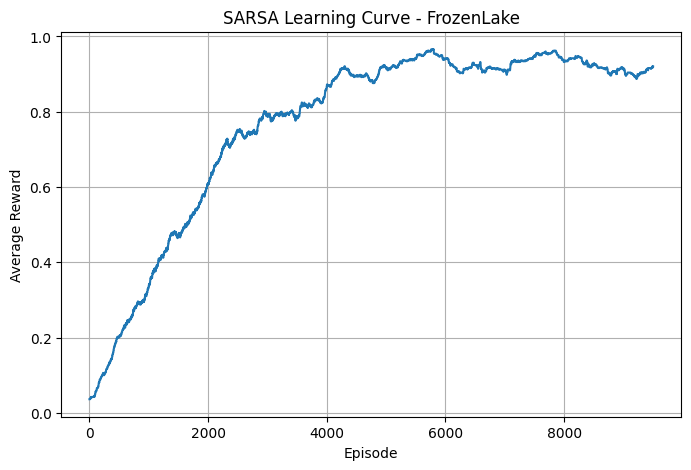

In [10]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("SARSA Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()